In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, calculate_stats_from_random_points, smooth_data, merge_datasets, slice_by_dates

In [191]:
remote_df_a = load_and_prepare_data('../data/processed/satellites/Sentinel2_bands_indices_TCT_20m_202405-202605.csv')
remote_df_a = handle_duplicate_values(remote_df_a)
remote_df_a = reindex_daily(remote_df_a)
remote_df_a = handle_outliers(remote_df_a, 3.0)
remote_df_a = handle_missing_values(remote_df_a, 'time')
remote_df_a = calculate_stats_from_random_points(remote_df_a, 10)
#remote_df_a = smooth_data(remote_df_a, None, 11, 2)

#z_df_a = remote_df_a.apply(zscore, nan_policy='omit')

In [192]:
def plot_mean_with_std(stats_df: pd.DataFrame, feature: str, nStd: int=1):
    """
    Plot the mean feature value over time with a shaded area representing +/- one standard deviation.
    """
    # Set a clean seaborn style for scientific plots
    sns.set_theme(style="whitegrid")
    
    # Initialize the matplotlib figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define the time axis (dataframe index) and the statistical series
    time_axis = stats_df.index
    mean = stats_df[f'{feature}_mean']
    std = stats_df[f'{feature}_std']
    
    # Calculate the upper and lower bounds for the standard deviation
    lower_bound = mean - (nStd*std)
    upper_bound = mean + (nStd*std)
    
    # Plot the mean line using seaborn
    sns.lineplot(
        x=time_axis, 
        y=mean, 
        label=f'mean {feature}', 
        color='gray',
        linewidth=2, 
        ax=ax
    )
    
    # Fill the area between lower and upper bounds using matplotlib
    ax.fill_between(
        time_axis, 
        lower_bound, 
        upper_bound, 
        color='gray',
        alpha=0.3,
        label='±1 std dev'
    )
    
    ax.set_ylabel(f'{feature} value')
    ax.set_xlabel('')
    ax.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    
    plt.show()

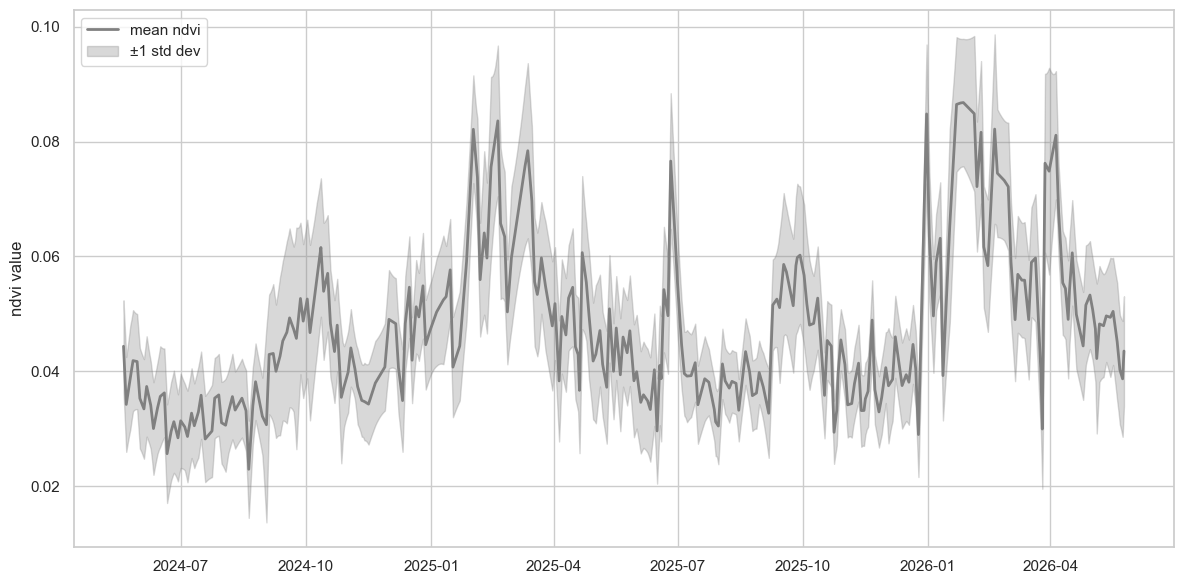

In [193]:
plot_mean_with_std(remote_df_a, 'ndvi', 1)